# 01b · X-ray Density Viewer

Visualise a CCP4 electron-density map alongside the CrossDocked pocket and the bound ligand — 2D orthogonal slices and an interactive 3D isosurface.

In [1]:
import math
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import gemmi
from rdkit import Chem

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
ELEM_COLOR = {"C": "gray", "N": "blue", "O": "red", "S": "goldenrod",
              "F": "green", "Cl": "lime", "P": "orange", "H": "white"}

## 1. Config

In [2]:
PDB_ID     = "14gs"
CCP4_FILE  = Path("data") / "14gs.ccp4"
POCKET_DIR = Path("..") / "voxbind" / "dataset" / "data" / "crossdocked_pocket10"

matches = sorted(POCKET_DIR.rglob(f"*{PDB_ID}*pocket10.pdb"))
if not matches:
    raise FileNotFoundError(f"No pocket PDB found for {PDB_ID} under {POCKET_DIR}")
POCKET_PDB = matches[0]
LIGAND_SDF = POCKET_PDB.with_name(POCKET_PDB.name.replace("_pocket10.pdb", ".sdf"))

print(f"CCP4 map   : {CCP4_FILE}")
print(f"Pocket PDB : {POCKET_PDB.relative_to(POCKET_DIR.parent)}")
print(f"Ligand SDF : {LIGAND_SDF.relative_to(POCKET_DIR.parent)}")

CCP4 map   : data/14gs.ccp4
Pocket PDB : crossdocked_pocket10/GSTP1_HUMAN_2_210_0/14gs_A_rec_20gs_cbd_lig_tt_min_0_pocket10.pdb
Ligand SDF : crossdocked_pocket10/GSTP1_HUMAN_2_210_0/14gs_A_rec_20gs_cbd_lig_tt_min_0.sdf


## 2. Load

In [3]:
# --- Density map ---
m = gemmi.read_ccp4_map(str(CCP4_FILE))
m.setup(float("nan"))
grid = m.grid
arr  = np.array(grid, dtype=np.float32)         # (nu, nv, nw)
cell = grid.unit_cell
nu, nv, nw = arr.shape

mean  = float(np.nanmean(arr))
sigma = float(np.nanstd(arr))


def cart_to_grid(xyz):
    """Cartesian (Å) → fractional → grid-index coordinates."""
    out = np.zeros_like(xyz, dtype=float)
    for i, (x, y, z) in enumerate(xyz):
        f = cell.fractionalize(gemmi.Position(float(x), float(y), float(z)))
        out[i] = [f.x * nu, f.y * nv, f.z * nw]
    return out


# --- Pocket atoms ---
st = gemmi.read_structure(str(POCKET_PDB))
pocket_atoms = [a for model in st for chain in model for res in chain for a in res]
pocket_xyz   = np.array([[a.pos.x, a.pos.y, a.pos.z] for a in pocket_atoms])
pocket_elems = [a.element.name for a in pocket_atoms]
pocket_grid  = cart_to_grid(pocket_xyz)

# --- Ligand atoms ---
mol = Chem.SDMolSupplier(str(LIGAND_SDF), removeHs=False, sanitize=False)[0]
conf = mol.GetConformer(0)
ligand_xyz   = np.array([list(conf.GetAtomPosition(i)) for i in range(mol.GetNumAtoms())])
ligand_elems = [a.GetSymbol() for a in mol.GetAtoms()]
ligand_grid  = cart_to_grid(ligand_xyz)

lig_centroid = ligand_grid.mean(axis=0)

print(f"Grid shape    : {nu} x {nv} x {nw}")
print(f"Unit cell     : a={cell.a:.2f}  b={cell.b:.2f}  c={cell.c:.2f} Å   β={cell.beta:.2f}°")
print(f"Map mean / σ  : {mean:.4f} / {sigma:.4f}")
print(f"Pocket atoms  : {len(pocket_elems)}")
print(f"Ligand atoms  : {len(ligand_elems)}")
print(f"Lig centroid  : u={lig_centroid[0]:.1f}  v={lig_centroid[1]:.1f}  w={lig_centroid[2]:.1f}")

Grid shape    : 60 x 72 x 50
Unit cell     : a=78.65  b=91.83  c=69.14 Å   β=98.25°
Map mean / σ  : 0.0000 / 0.1973
Pocket atoms  : 255
Ligand atoms  : 22
Lig centroid  : u=21.6  v=5.2  w=20.3


## 3. Visualize

### 3a. Orthogonal planes

Three 2D slices through the ligand centroid; pocket atoms (small, faint) and ligand atoms (large, outlined) are overlaid. Cyan = +1.5σ contour, dashed orange = −3σ.

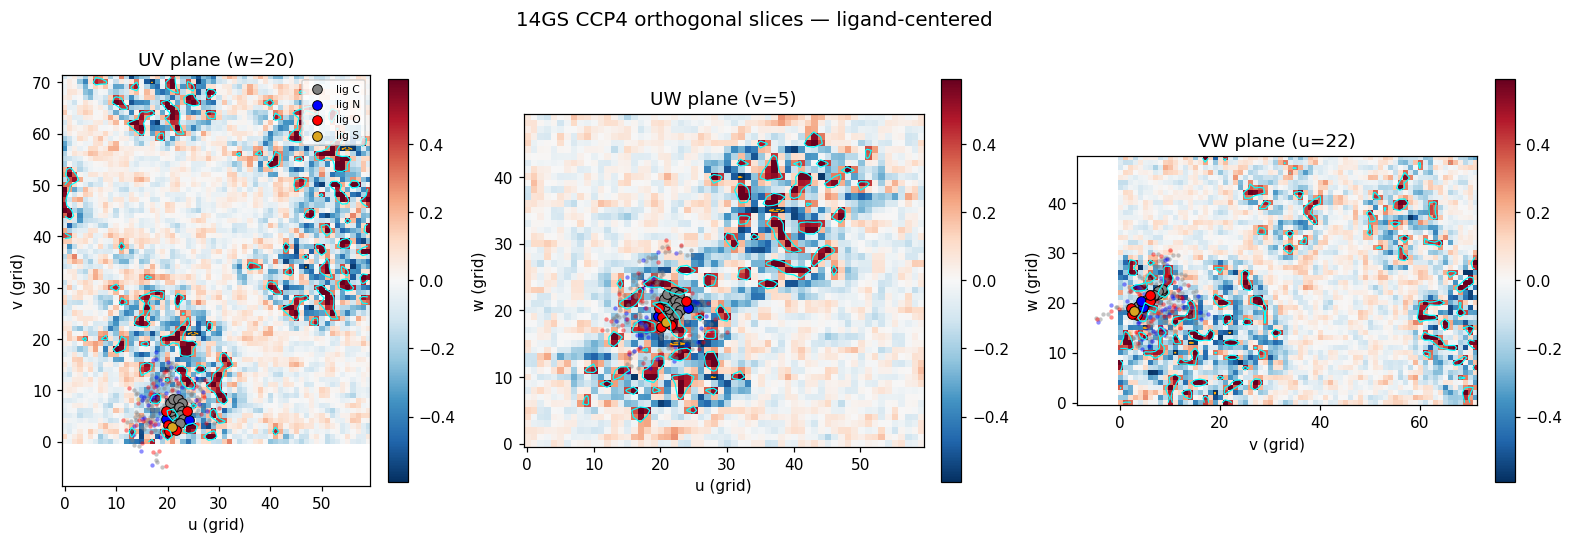

In [4]:
ci = int(np.clip(round(lig_centroid[0]), 0, nu - 1))
cj = int(np.clip(round(lig_centroid[1]), 0, nv - 1))
ck = int(np.clip(round(lig_centroid[2]), 0, nw - 1))

vmin, vmax = mean - 3 * sigma, mean + 3 * sigma

slice_specs = [
    (f"UV plane (w={ck})", arr[:, :, ck],
     (pocket_grid[:, 0], pocket_grid[:, 1]),
     (ligand_grid[:, 0], ligand_grid[:, 1]),
     "u (grid)", "v (grid)"),
    (f"UW plane (v={cj})", arr[:, cj, :],
     (pocket_grid[:, 0], pocket_grid[:, 2]),
     (ligand_grid[:, 0], ligand_grid[:, 2]),
     "u (grid)", "w (grid)"),
    (f"VW plane (u={ci})", arr[ci, :, :],
     (pocket_grid[:, 1], pocket_grid[:, 2]),
     (ligand_grid[:, 1], ligand_grid[:, 2]),
     "v (grid)", "w (grid)"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (title, slc, (px, py), (lx, ly), xl, yl) in zip(axes, slice_specs):
    im = ax.imshow(slc.T, origin="lower", cmap="RdBu_r",
                   vmin=vmin, vmax=vmax, aspect="equal")
    ax.contour(slc.T, levels=[mean + 1.5 * sigma],
               colors=["cyan"], linewidths=0.8)
    ax.contour(slc.T, levels=[mean - 3.0 * sigma],
               colors=["orange"], linewidths=0.8, linestyles="dashed")

    for elem in sorted(set(pocket_elems)):
        mask = np.array([e == elem for e in pocket_elems])
        ax.scatter(np.array(px)[mask], np.array(py)[mask],
                   c=ELEM_COLOR.get(elem, "purple"), s=8,
                   alpha=0.45, linewidths=0)

    for elem in sorted(set(ligand_elems)):
        mask = np.array([e == elem for e in ligand_elems])
        ax.scatter(np.array(lx)[mask], np.array(ly)[mask],
                   c=ELEM_COLOR.get(elem, "purple"), s=40,
                   edgecolors="black", linewidths=0.6, label=f"lig {elem}")

    ax.set_title(title)
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

axes[0].legend(fontsize=7, loc="upper right")
plt.suptitle(f"{PDB_ID.upper()} CCP4 orthogonal slices — ligand-centered", fontsize=13)
plt.tight_layout()
plt.show()

### 3b. 3D density around pocket + ligand

Sub-box around the ligand centroid. **Blue** = +1.5σ (positive density), **red** = −3σ (missing / negative density). Pocket atoms are small markers; ligand atoms are larger with a dark outline.

In [5]:
# Sub-box around ligand centroid (grid indices)
R = 18
i0, i1 = max(0, ci - R), min(nu, ci + R)
j0, j1 = max(0, cj - R), min(nv, cj + R)
k0, k1 = max(0, ck - R), min(nw, ck + R)
sub = arr[i0:i1, j0:j1, k0:k1]

# Grid indices → Cartesian Å (monoclinic: x = a·fa + c·cos(β)·fc)
beta_rad = math.radians(cell.beta)
a_len, b_len, c_len = cell.a, cell.b, cell.c

ii = np.arange(i0, i1, dtype=float) / nu
jj = np.arange(j0, j1, dtype=float) / nv
kk = np.arange(k0, k1, dtype=float) / nw
Fi, Fj, Fk = np.meshgrid(ii, jj, kk, indexing="ij")

Xc = a_len * Fi + c_len * math.cos(beta_rad) * Fk
Yc = b_len * Fj
Zc = c_len * math.sin(beta_rad) * Fk

pos_thresh = mean + 1.5 * sigma
neg_thresh = mean - 3.0 * sigma

traces = [
    go.Isosurface(
        x=Xc.ravel(), y=Yc.ravel(), z=Zc.ravel(), value=sub.ravel(),
        isomin=pos_thresh, isomax=pos_thresh, surface_count=1,
        colorscale=[[0, "blue"], [1, "blue"]],
        showscale=False, opacity=0.30, name="+1.5σ",
        caps=dict(x_show=False, y_show=False, z_show=False),
    ),
    go.Isosurface(
        x=Xc.ravel(), y=Yc.ravel(), z=Zc.ravel(), value=sub.ravel(),
        isomin=neg_thresh, isomax=neg_thresh, surface_count=1,
        colorscale=[[0, "red"], [1, "red"]],
        showscale=False, opacity=0.20, name="−3σ",
        caps=dict(x_show=False, y_show=False, z_show=False),
    ),
]

for elem in sorted(set(pocket_elems)):
    mask = np.array([e == elem for e in pocket_elems])
    xyz  = pocket_xyz[mask]
    traces.append(go.Scatter3d(
        x=xyz[:, 0], y=xyz[:, 1], z=xyz[:, 2], mode="markers",
        marker=dict(size=3, color=ELEM_COLOR.get(elem, "purple"), opacity=0.55),
        name=f"pocket {elem}",
    ))

for elem in sorted(set(ligand_elems)):
    mask = np.array([e == elem for e in ligand_elems])
    xyz  = ligand_xyz[mask]
    traces.append(go.Scatter3d(
        x=xyz[:, 0], y=xyz[:, 1], z=xyz[:, 2], mode="markers",
        marker=dict(size=6, color=ELEM_COLOR.get(elem, "purple"),
                    line=dict(color="black", width=1), opacity=0.95),
        name=f"ligand {elem}",
    ))

fig = go.Figure(traces)
fig.update_layout(
    title=f"{PDB_ID.upper()} CCP4 — 3D isosurface · pocket + ligand",
    scene=dict(xaxis_title="X (Å)", yaxis_title="Y (Å)", zaxis_title="Z (Å)",
               aspectmode="data"),
    width=800, height=650,
)
fig.show()